# Required Assignment 27
## Efficient product recognition deployment experiment
**Cheah Sze Zheng**

This notebook uses the assignment's permitted **pseudocode route** for model training and phone
benchmarking because retailer images, labels and target-device access were not supplied.
The storage calculation and MLflow logging cells below execute. They are planning evidence,
not measurements of trained-model accuracy, mobile latency or exported model size.

## Setup and method
```bash
python -m pip install pandas matplotlib mlflow-skinny==3.5.1
```
Source: Keras Applications publishes rounded parameter counts (ResNet50 25.6M;
MobileNetV2 3.5M), including ImageNet heads: https://keras.io/api/applications/.
Compute raw weight payload as parameter count × bits / 8. Decimal MB = 1,000,000 bytes.
The calculation excludes metadata, quantisation scales, biases that retain greater precision,
activations and runtime buffers. A retail classification head changes the actual counts.

In [1]:
from pathlib import Path
import json, importlib.metadata
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
print({p:importlib.metadata.version(p) for p in ['pandas','matplotlib','mlflow-skinny']})
records = [
 {'candidate':'ResNet50 FP32','parameters_millions':25.6,'bits_per_weight':32},
 {'candidate':'MobileNetV2 FP32','parameters_millions':3.5,'bits_per_weight':32},
 {'candidate':'MobileNetV2 INT8','parameters_millions':3.5,'bits_per_weight':8}
]
df = pd.DataFrame(records)
df['estimated_raw_weight_MB'] = df.parameters_millions * df.bits_per_weight / 8
print(df.to_string(index=False))
assert df.estimated_raw_weight_MB.tolist() == [102.4,14.0,3.5]
print('Within-MobileNet theoretical reduction factor:', 14/3.5)

{'pandas': '3.0.1', 'matplotlib': '3.11.2', 'mlflow-skinny': '3.5.1'}
       candidate  parameters_millions  bits_per_weight  estimated_raw_weight_MB
   ResNet50 FP32                 25.6               32                    102.4
MobileNetV2 FP32                  3.5               32                     14.0
MobileNetV2 INT8                  3.5                8                      3.5
Within-MobileNet theoretical reduction factor: 4.0


## Storage comparison
The theoretical fourfold reduction applies to weights converted from FP32 to INT8.
The larger cross-architecture reduction combines a change of architecture and precision.
Neither ratio predicts actual end-to-end speedup.

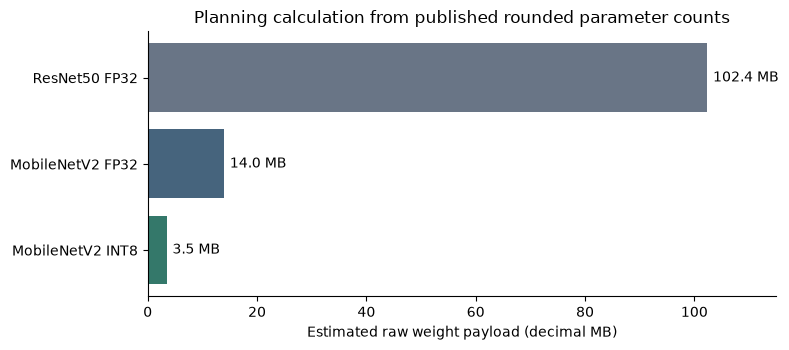

In [2]:
fig, ax = plt.subplots(figsize=(8,3.6))
bars = ax.barh(df.candidate, df.estimated_raw_weight_MB, color=['#697586','#46647d','#34786a'])
ax.invert_yaxis()
ax.set_xlim(0,115)
ax.set_xlabel('Estimated raw weight payload (decimal MB)')
ax.set_title('Planning calculation from published rounded parameter counts')
ax.bar_label(bars, fmt='%.1f MB', padding=4)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
fig.savefig('assignment27_storage.png',dpi=180,bbox_inches='tight')
plt.show()

## MLflow planning logs
These are genuine local MLflow runs for an analytical calculation. They do not claim a model was trained,
quantised or registered. Model registration and mobile benchmarking remain in the procedure below.

In [3]:
tracking_dir = Path('assignment27_mlruns').resolve()
mlflow.set_tracking_uri(tracking_dir.as_uri())
mlflow.set_experiment('assignment27_storage_planning')
run_records=[]
for record in df.to_dict(orient='records'):
    with mlflow.start_run(run_name=record['candidate']) as run:
        mlflow.set_tags({'evidence_type':'analytical_estimate','training_executed':'false',
                         'source':'https://keras.io/api/applications/'})
        mlflow.log_params({k:record[k] for k in ['candidate','parameters_millions','bits_per_weight']})
        mlflow.log_metric('estimated_raw_weight_MB',record['estimated_raw_weight_MB'])
        mlflow.log_artifact('assignment27_storage.png')
        run_records.append({'run_id':run.info.run_id,**record,'evidence_type':'analytical_estimate'})
Path('assignment27_experiment_logs.json').write_text(json.dumps(run_records,indent=2))
df.to_csv('assignment27_storage_estimates.csv',index=False)
print(json.dumps(run_records,indent=2))

2026/09/20 13:45:42 INFO mlflow.tracking.fluent: Experiment with name 'assignment27_storage_planning' does not exist. Creating a new experiment.


[
  {
    "run_id": "6733b242d48d4de2857b01abe1e217b6",
    "candidate": "ResNet50 FP32",
    "parameters_millions": 25.6,
    "bits_per_weight": 32,
    "estimated_raw_weight_MB": 102.4,
    "evidence_type": "analytical_estimate"
  },
  {
    "run_id": "bccafc95ba2240bfbcbe70d1dc17ef27",
    "candidate": "MobileNetV2 FP32",
    "parameters_millions": 3.5,
    "bits_per_weight": 32,
    "estimated_raw_weight_MB": 14.0,
    "evidence_type": "analytical_estimate"
  },
  {
    "run_id": "a44141a4a38e49c08628fa3d90efc309",
    "candidate": "MobileNetV2 INT8",
    "parameters_millions": 3.5,
    "bits_per_weight": 8,
    "estimated_raw_weight_MB": 3.5,
    "evidence_type": "analytical_estimate"
  }
]


## Model experiment pseudocode
**Not executed.** Required inputs are a versioned retail image manifest with product labels,
calibration images drawn only from training data and a target-device benchmark harness.
Partition near-duplicate product-photo sessions together to reduce leakage.

```python
set_seeds(42)
train, validation, test = split_by_photo_session_and_time(retail_manifest)
assert_no_duplicate_image_hashes_across_splits(train, validation, test)
calibration = representative_subset(train, size=300, stratify=['product','lighting','camera'])

for architecture in ['ResNet50', 'MobileNetV2']:
    base = load_imagenet_backbone(architecture, include_top=False)
    model = attach_retail_classifier(base, number_of_products)
    model = train_head_then_finetune(model, train, validation,
                                    architecture_specific_preprocessing=True)
    save_model_and_label_mapping(model)
    fp32 = export_mobile_float_model(model)
    log_heldout_quality_and_exported_bytes(fp32, test)

    if architecture == 'MobileNetV2':
        converter = TFLiteConverter.from_keras_model(model)
        converter.optimizations = [Optimize.DEFAULT]
        converter.representative_dataset = calibration_generator(calibration)
        converter.target_spec.supported_ops = [OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = int8
        converter.inference_output_type = int8
        int8_model = converter.convert()  # fail instead of silently using unsupported float ops
        save(int8_model, 'retail_mobilenet_int8.tflite')
        # Apply the interpreter's input quantisation scale and zero-point before inference;
        # dequantise output scores using their own scale and zero-point.
        log_heldout_quality_and_exported_bytes(int8_model, test)

for artefact in exported_models:
    for phone in lowest_and_typical_supported_phones:
        load_model(artefact, phone)
        record_cold_start_separately()
        warm_up(50)
        timings = run_batch_one_inference(500, fixed_images, fixed_threads=True)
        log(p50(timings), p95(timings), peak_memory(), device_os_threads_and_temperature())

compare_same_testset_and_devices_in_mlflow()
candidate = select_under_proposed_gates(max_accuracy_drop_pp=1, p95_ms=150)
if candidate and human_release_approval():
    register_model_version(candidate, source_run_id, data_hash, code_commit)
    deploy_canary_by_immutable_hash(candidate)
    promote_only_after_canary_quality_and_reliability_checks()
```

## Checks and handoff
- Executed: storage arithmetic, labelled plot and MLflow planning runs.
- Unexecuted: retail training, quantisation, test-set evaluation, phone benchmarks and registry promotion.
- No fabricated accuracy, latency or model-registration result is included.
- Proposed targets require validation with the retailer; compare per-category quality and peak memory,
  not just total accuracy or file size.

MLflow evidence accompanies the notebook as JSON. Install full `mlflow==3.5.1` if a local tracking UI is desired.
The written report explains the architecture, INT8 trade-offs, version management and deployment decision.